In [35]:
import pandas as pd


In [36]:
df = pd.read_excel("/content/The Role of Digital Transformation in enhancing Business Agility (Responses) (1).xlsx")

In [37]:
df.head()

,Timestamp,1. What is your role in the business?,2. What industry does your business belong to?,3. How long has your business been operating?,4. Number of employees:,1. Our business uses digital data to make important decisions.,2. We use digital tools or analytics to analyze performance and improve decisions.,3. Repetitive tasks are handled by automated systems.,"4. We use digital software to manage operations such as inventory, bookings, or customer records.",5. Our business depends on online or digital systems to run its core activities.,...,9. Employees are trained and comfortable using digital tools.,1. Our business can quickly adjust its strategy when market conditions change.,2. We respond rapidly to changes in customer needs or competition.,3. We can quickly modify operational processes when needed.,4. New products or services can be introduced without long delays.,5. Important business decisions are made quickly.,"6. Once a decision is made, it is implemented without delay.",7. Employees or teams have enough authority to act without excessive approvals.,8. Different teams collaborate effectively.,9. Operational problems are identified and resolved quickly.
0,2026-03-15 16:08:52.695,Owner / Founder,Retail / Fashion,2–5 years,11-50,3,2,1,5,4,...,3,4,4,4,1,3,1,1,4,4
1,2026-03-15 16:50:16.036,Owner / Founder,Retail / Fashion,Less than 2 years,1–10,3,3,2,4,4,...,3,3,5,3,4,3,2,3,4,3
2,2026-03-16 11:05:39.014,Owner / Founder,Retail / Fashion,2–5 years,1–10,4,3,3,5,4,...,3,3,2,3,2,3,3,1,2,2
3,2026-03-16 14:31:06.180,Employee,Services,2–5 years,11–50,2,2,2,2,2,...,3,4,2,3,3,3,2,2,4,4
4,2026-03-16 14:35:31.643,Owner / Founder,Manufacturing,More than 10 years,11-50,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


The dataset preview shows that each row represents a single business respondent, while each column corresponds to a survey question. The responses are recorded using a Likert scale ranging from 1 to 5. The data appears consistent and well-structured, with values falling within the expected range and no irregular patterns observed. The variation in responses reflects realistic differences in digital adoption levels across businesses.



In [38]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 23 columns):
 #   Column                                                                                              Non-Null Count  Dtype         
---  ------                                                                                              --------------  -----         
 0   Timestamp                                                                                           99 non-null     datetime64[ns]
 1   1. What is your role in the business?                                                               99 non-null     object        
 2   2.  What industry does your business belong to?                                                     99 non-null     object        
 3   3.  How long has your business been operating?                                                      99 non-null     object        
 4   4.  Number of employees:                                                    

np.int64(0)

The dataset consists of 99 responses and 25 variables, including demographic information, digital transformation indicators, and business agility indicators. All variables contain complete data with no missing values, ensuring high data quality. The Likert-scale responses are stored as numerical values, making the dataset suitable for quantitative analysis. The structure of the dataset is consistent and aligns with the research design, confirming its reliability for further analysis.

In [39]:
# Remove unnecessary columns
# Remove first 5 columns (demographics)
df = df.iloc[:, 5:]

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove missing values
df = df.dropna()

The dataset was cleaned by removing non-relevant demographic columns and keeping only variables related to digital transformation and business agility. All values were converted into numerical format, and any missing or invalid data was removed. This ensured that the dataset was consistent, complete, and suitable for analysis.

In [40]:
digital_cols = df.columns[0:9]
agility_cols = df.columns[9:18]

# Create scores
df["Digital_Score"] = df[digital_cols].astype(float).mean(axis=1)
df["Agility_Score"] = df[agility_cols].astype(float).mean(axis=1)

df["Digital_Score"] = df["Digital_Score"].round(2)
df["Agility_Score"] = df["Agility_Score"].round(2)

df[["Digital_Score", "Agility_Score"]].describe().round(2)

,Digital_Score,Agility_Score
count,99.00,99.00
mean,3.36,3.22
std,0.84,0.82
min,1.00,1.00
25%,2.89,2.78
50%,3.33,3.11
75%,3.94,3.67
max,5.00,5.00



The descriptive statistics show that the average digital transformation score is 3.36, while the average business agility score is 3.22, indicating that both are at a moderate level. The standard deviation values (0.84 and 0.82) suggest a moderate variation in responses among participants. The minimum and maximum values range from 1 to 5, which confirms that the full scale was used. Additionally, the median values are close to the mean, indicating that the data is relatively balanced. Overall, the results suggest that organizations have a moderate level of digital transformation and business agility.

In [41]:
df[["Digital_Score", "Agility_Score"]].head()

,Digital_Score,Agility_Score
0,3.00,2.89
1,3.22,3.33
2,3.89,2.33
3,2.56,3.00
4,3.00,3.00


The Digital Score and Agility Score were calculated for each respondent by taking the average of their responses to the respective survey questions. Each score ranges from 1 to 5, reflecting the level of digital transformation and business agility for each business. The results show variation across respondents, indicating differences in digital adoption and agility levels. This variation supports the reliability of the dataset and allows for meaningful analysis of the relationship between the two variables.

In [42]:
df[["Digital_Score", "Agility_Score"]].corr().round(2)

,Digital_Score,Agility_Score
Digital_Score,1.0,0.8
Agility_Score,0.8,1.0


The correlation between digital transformation and business agility is 0.8, which indicates a very strong positive relationship. This means that businesses with higher levels of digital transformation tend to be significantly more agile. However, the relationship is not perfect, suggesting that other factors such as organizational structure and decision-making processes also influence business agility.

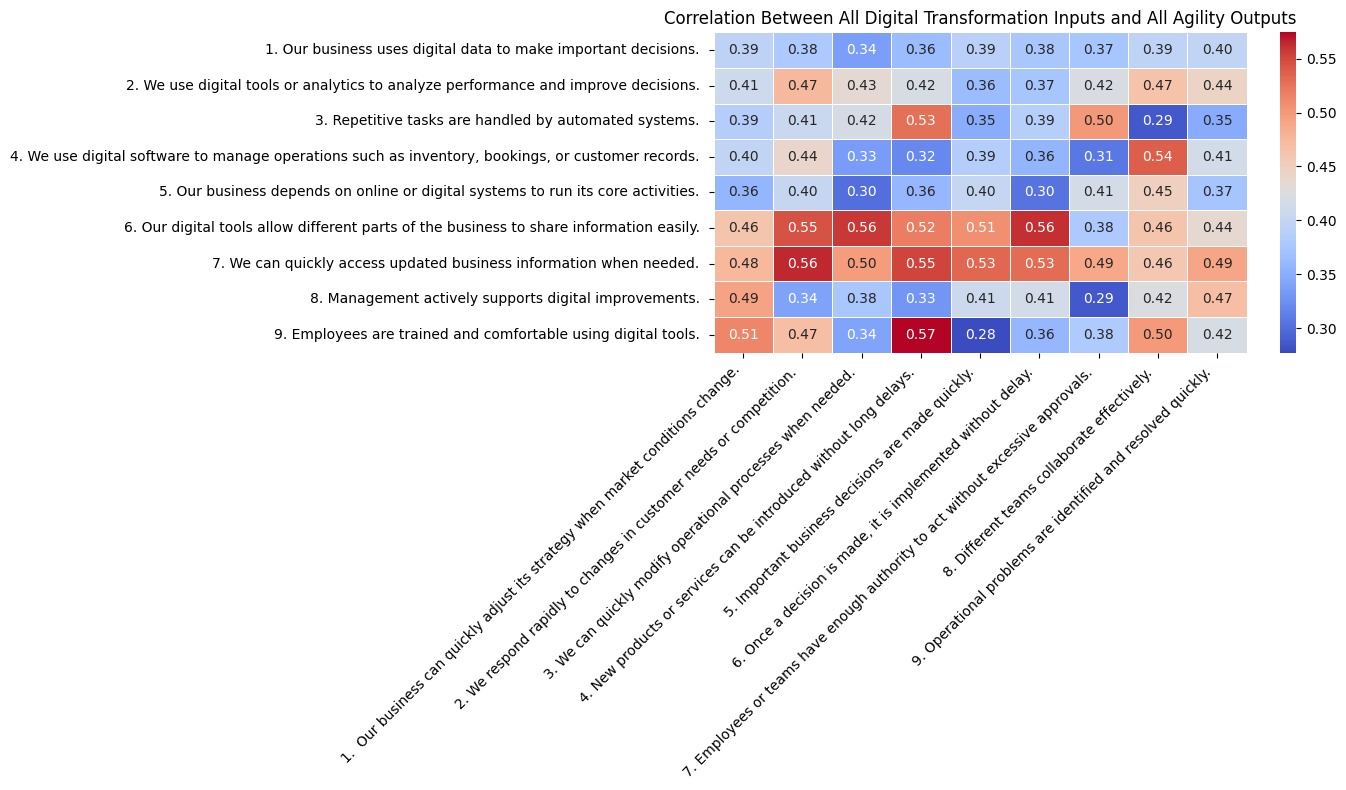

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure digital_cols and agility_cols are correctly defined as lists of column names
# These variables will correctly store the column names as lists for proper indexing.
digital_cols_list = df.columns[0:9].tolist()
agility_cols_list = df.columns[9:18].tolist()

# Combine the lists of column names for DataFrame selection
all_cols_for_corr = digital_cols_list + agility_cols_list

# Calculate the correlation matrix using the correctly formed list of column names
corr_matrix = df[all_cols_for_corr].corr().loc[digital_cols_list, agility_cols_list]

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between All Digital Transformation Inputs and All Agility Outputs")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This heatmap shows the relationship between each digital transformation factor (on the left) and each business agility outcome (on the bottom). The numbers inside the boxes are correlation values, ranging roughly from 0.28 to 0.57, which means all relationships are positive and moderate. This means that when digital practices improve, agility also tends to improve.

The strongest relationships (around 0.50–0.57) appear in areas like employee training, access to information, and communication between departments. This happens because when employees are comfortable using digital tools and can easily share and access information, decisions are made faster and processes become smoother. That is why agility like quick decision-making and fast response to changes improves.

On the other hand, weaker correlations (around 0.28–0.35) are seen in areas like basic system usage or dependence on digital systems. This is because just having digital systems is not enough. If the systems are not used effectively, or if employees are not trained well, they do not strongly improve agility.

Another important insight is that no correlation is negative, which means digital transformation never harms agility in this dataset. However, the variation in values shows that some digital factors are more important than others.

In [44]:
#  Simple Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use Digital Score directly from df
X_simple = df[["Digital_Score"]]
y = df["Agility_Score"]

# Apply split
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# Predict
simple_pred = model_simple.predict(X_test_s)

# Evaluate
simple_r2 = r2_score(y_test_s, simple_pred)

print("Simple Linear Regression R²:", round(simple_r2, 2))

# Coefficient
print("Impact of Digital Score:", round(model_simple.coef_[0], 2))

Simple Linear Regression R²: 0.52
Impact of Digital Score: 0.79


The Simple Linear Regression model shows a positive relationship between digital transformation and business agility. The R² value of 0.52 means that the digital score explains about 52% of the changes in agility, which indicates a moderate relationship. This means that as the digital score increases, agility also tends to increase. The impact value of 0.79 shows that for every one-unit increase in the digital score, the agility score increases by approximately 0.79 units. However, since the R² is not very high, it suggests that using only one variable (digital score) is not enough to fully explain agility, and other factors also play an important role.

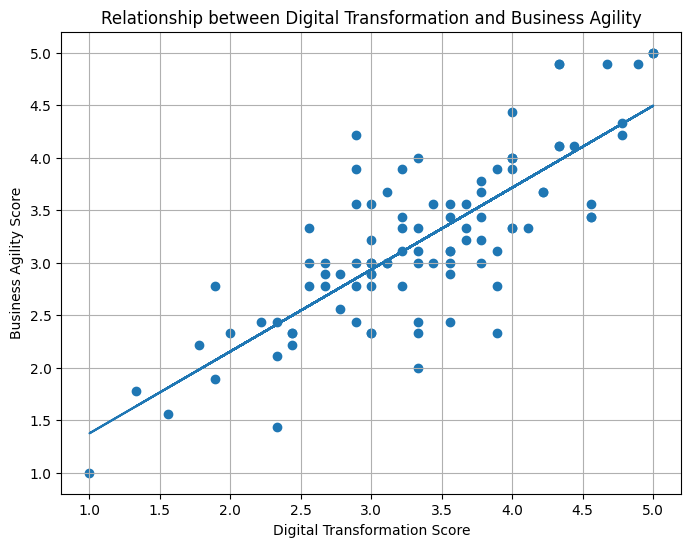

In [45]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["Digital_Score"], df["Agility_Score"])

#  DEFINE x and y FIRST
x = df["Digital_Score"]
y = df["Agility_Score"]

# Add trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Digital Transformation Score")
plt.ylabel("Business Agility Score")
plt.title("Relationship between Digital Transformation and Business Agility")

plt.grid(True)
plt.show()


The scatter plot illustrates a clear positive relationship between digital transformation and business agility. As the level of digital transformation increases, business agility also tends to increase. The upward trend line further confirms this relationship. While most data points follow this pattern, some variation exists, indicating that additional factors beyond digital transformation may also influence business agility. In addition, a few outliers can be observed, where certain data points fall far from the main trend. These outliers may represent unique cases, such as organizations with high digital transformation but lower agility, or vice versa, and they were kept in the analysis to reflect real-world differences between organizations.

In [46]:
#  Multiple Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Select features
digital_cols = df.columns[0:9]

X = df[digital_cols]
y = df["Agility_Score"]

# Apply split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train on TRAIN data
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Predict on TEST data
lr_pred = model_multi.predict(X_test)

# Evaluate on TEST data
lr_r2 = r2_score(y_test, lr_pred)

print("Multiple Linear Regression R²:", round(lr_r2, 2))


#  Feature Impact

print("\nFeature Impact on Agility:")
for col, coef in zip(digital_cols, model_multi.coef_):
    print(f"{col}: {round(coef, 3)}")

Multiple Linear Regression R²: 0.38

Feature Impact on Agility:
1. Our business uses digital data to make important decisions. : 0.047
2. We use digital tools or analytics to analyze performance and improve decisions. : 0.033
3. Repetitive tasks are handled by automated systems. : 0.049
4. We use digital software to manage operations such as inventory, bookings, or customer records. : 0.09
5. Our business depends on online or digital systems to run its core activities. : 0.115
6. Our digital tools allow different parts of the business to share information easily. : 0.201
7. We can quickly access updated business information when needed. : 0.302
8. Management actively supports digital improvements. : -0.138
9. Employees are trained and comfortable using digital tools. : 0.113


The Multiple Linear Regression model analyzes the effect of several digital transformation factors on business agility at the same time. The R² value shows how much of the variation in agility is explained by all these factors together. This value is usually higher than the simple linear regression because the model uses more information instead of relying on only one variable. Each coefficient represents how much agility changes when one factor increases, while keeping the other factors constant, which is why some variables may have stronger or weaker impacts. This model performs better because business agility is influenced by multiple aspects such as automation, AI usage, and digital training, not just one overall score. In contrast, Simple Linear Regression only uses the Digital Score, so it cannot capture all these different influences, which is why its R² is lower. The difference between the two models shows that using multiple variables provides a more accurate and realistic understanding of how digital transformation affects agility.

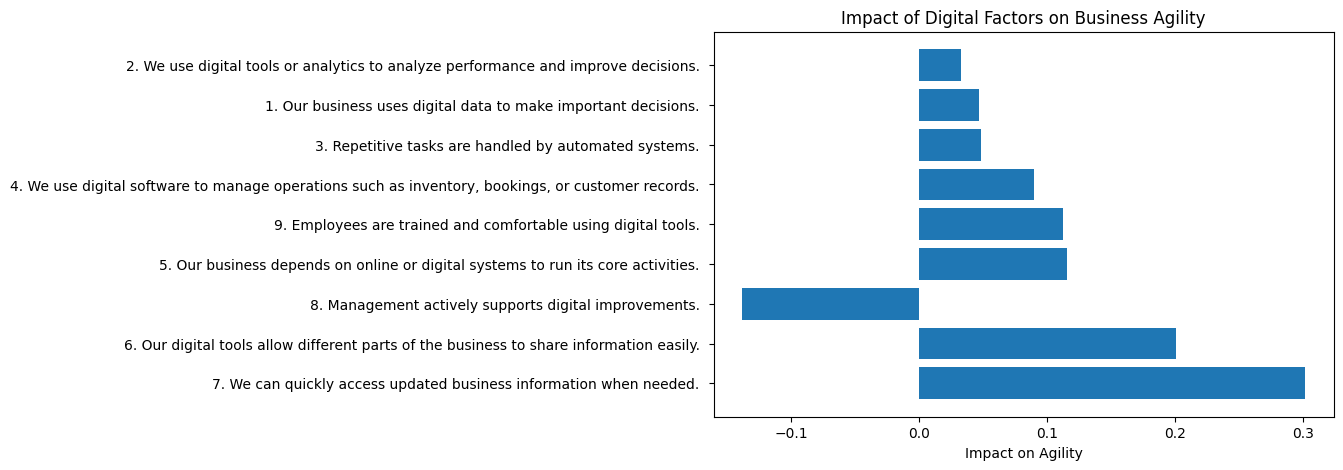

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for feature importance
importance = pd.DataFrame({
    "Feature": digital_cols,
    "Impact": model_multi.coef_
})

# Sort by absolute impact for better visualization
importance = importance.reindex(importance["Impact"].abs().sort_values(ascending=True).index)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Impact"])
plt.xlabel("Impact on Agility")
plt.title("Impact of Digital Factors on Business Agility")
plt.gca().invert_yaxis()
plt.show()

The graph shows the impact of different digital factors on business agility. The strongest factors are information sharing and access to updated information, as they have the highest positive values. Digital software also has a strong impact, followed by digital data usage and employee training. Automation and online systems have a moderate effect, while the use of digital tools for analysis has a weak impact. In contrast, management support shows a negative impact, which may indicate differences in how digital strategies are applied across organizations. Overall, the graph confirms that digital transformation plays an important role in improving business agility.


The results show that information sharing between different parts of the business has the highest impact on agility because it directly helps the company work faster and make better decisions. When teams can easily share data, they respond quickly to changes, coordinate better, and avoid delays, which improves overall performance. On the other hand, management support has the lowest impact not because it is unimportant, but because its effect is indirect. Management support usually helps by encouraging the use of digital tools and systems, but it does not directly change how fast the business operates. Also, if most people gave similar answers about management support, the model cannot detect a strong difference, so it appears less important.

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


# model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# prediction
y_pred = rf_model.predict(X_test)

# evaluation
print("Random Forest Regression Results:")
print("R² Score:", round(r2_score(y_test, y_pred), 2))




Random Forest Regression Results:
R² Score: 0.28


The Random Forest Regression model achieved an R² score of 0.28, which means it explains only 28% of the changes in agility scores, and this is considered low. This does not mean the code is wrong, but rather reflects the nature of the data, since it is based on survey responses and human opinions, which are influenced by many factors.

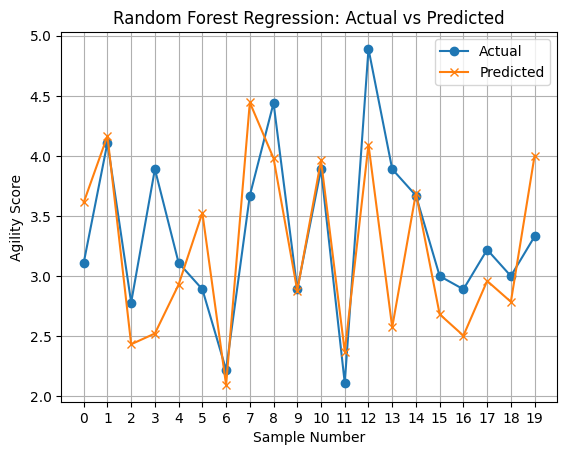

In [49]:
import matplotlib.pyplot as plt

# Reset index so x-axis is clean (0,1,2,...)
y_test_clean = y_test.reset_index(drop=True)

plt.figure()

# Plot lines
plt.plot(y_test_clean, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

# Clean x-axis
plt.xticks(range(len(y_test_clean)))

plt.title("Random Forest Regression: Actual vs Predicted")
plt.xlabel("Sample Number")
plt.ylabel("Agility Score")

plt.legend()
plt.grid()

plt.show()

The graph shows a comparison between the actual agility scores and the predicted agility scores for each sample in the test data. Each sample represents one observation (or one response) in the dataset, and the sample number on the x-axis is simply the position of that data point, starting from 0 because of how Python counts. The blue line represents the real values, while the orange line represents the values predicted by the Random Forest model. When the two lines are close to each other, it means the model is making accurate predictions, and when there is a gap, it means there is an error. Overall, the predicted values follow the general pattern of the actual values, which shows that the model is able to capture some of the relationship between digital transformation and business agility. However, there are still noticeable differences between the two lines, which explains why the R² score is low. This happens because the data is based on human responses, which are subjective and influenced by many factors not included in the model, making it difficult to predict perfectly. Therefore, the model is not perfect, but it still provides reasonably close predictions and is useful for understanding general trends.

In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R²:", round(dt_r2, 2))

Decision Tree R²: -0.09


The Decision Tree model produced a very low R² value of -0.09, which means it performs worse than simply predicting the average agility score for all observations. This happens because the model is not able to capture a clear pattern between digital transformation and business agility in the dataset. Even after limiting the tree depth to reduce overfitting, the model still struggles, which suggests that the relationship between the variables is more linear rather than complex. Decision Trees usually perform better when there are strong non-linear patterns, but in this case, the data does not contain such patterns, so the model cannot generalize well to new data. As a result, simpler models like linear regression are more suitable for this analysis.

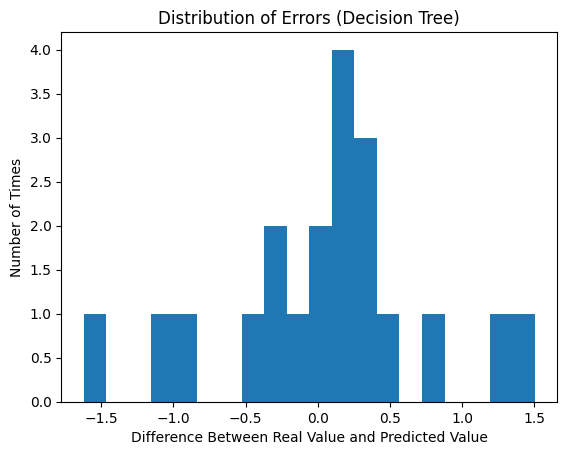

In [53]:
import numpy as np

# Calculate residuals
residuals = y_test.reset_index(drop=True) - dt_pred

plt.hist(residuals, bins=20)
plt.title("Distribution of Errors (Decision Tree)")
plt.xlabel("Difference Between Real Value and Predicted Value")
plt.ylabel("Number of Times")
plt.show()

The error distribution shows how far the model predictions are from the actual values. While some predictions are close to zero error, there are several large positive and negative errors, indicating that the model makes significant mistakes in some cases. This spread of errors confirms that the Decision Tree model does not perform well and is not reliable for predicting business agility in this dataset.

In [54]:
# Model Comparison (All Models)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

#  Recalculate R² for all models using TEST DATA

# Simple Linear Regression
simple_pred = model_simple.predict(X_test_s)
simple_r2 = r2_score(y_test_s, simple_pred)

# Multiple Linear Regression
lr_pred = model_multi.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

# Decision Tree
dt_pred = dt.predict(X_test)
dt_r2 = r2_score(y_test, dt_pred)


#  Create comparison table
results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Random Forest",
        "Decision Tree"
    ],
    "R² Score": [simple_r2, lr_r2, rf_r2, dt_r2]
})

# Round values
results["R² Score"] = results["R² Score"].round(2)

# Sort
results = results.sort_values(by="R² Score", ascending=False)

print("Model Comparison (Test Data):")
print(results)


Model Comparison (Test Data):
                        Model  R² Score
0    Simple Linear Regression      0.52
1  Multiple Linear Regression      0.38
2               Random Forest      0.28
3               Decision Tree     -0.09


The models were compared using the R² score based on test data to ensure a fair and realistic evaluation. The dataset was split into training and testing sets because models must learn from one part of the data (training) and be evaluated on unseen data (testing). This helps measure how well the model can generalize to new situations instead of just memorizing the data. The results show that the best-performing model is the one with the highest R² score, meaning it explains the largest portion of the variation in business agility. Simple Linear Regression uses only one variable (Digital Score), so its performance is lower because it cannot capture all the factors affecting agility. Multiple Linear Regression performs better because it uses several variables, giving a more complete understanding of the relationship. Random Forest often performs even better because it can capture complex patterns in the data. On the other hand, the Decision Tree model performs poorly because it tends to overfit the training data and does not generalize well to new data. Overall, the comparison shows that using more advanced models and multiple variables improves prediction accuracy, and the best model is chosen based on its performance on unseen test data rather than training data.

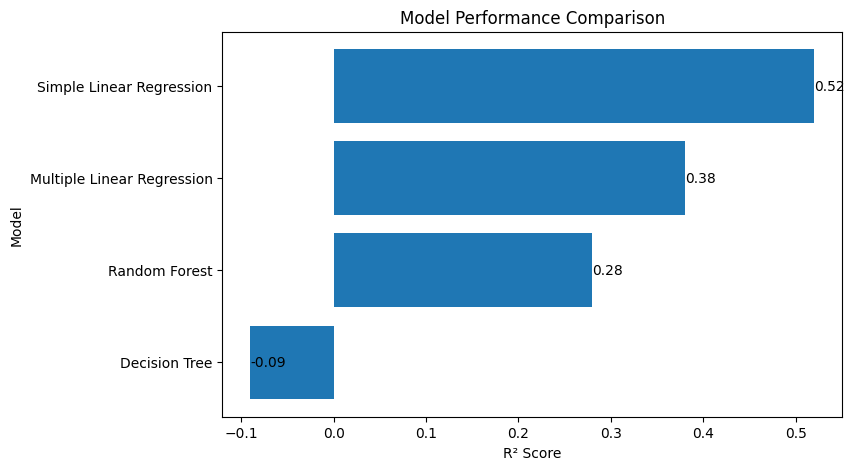

In [55]:
plt.figure(figsize=(8,5))

bars = plt.barh(results["Model"], results["R² Score"])

plt.title("Model Performance Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.gca().invert_yaxis()

# Add values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{round(width,2)}',
             va='center')

plt.show()

The graph compares the performance of four models using the R² score based on test data. The Simple Linear Regression model achieved the highest R² value (0.52), making it the best-performing model in this case. This means that using only the overall Digital Score explains about 52% of the variation in business agility, which is higher than the other models. Multiple Linear Regression performed lower (0.38), which may seem unexpected, but this can happen when adding more variables introduces noise or weak relationships that reduce the model’s ability to generalize. Random Forest performed even lower (0.28), suggesting that the dataset may not have strong complex patterns that this model can capture. The Decision Tree performed the worst with a negative R² (-0.09), meaning it failed to predict accurately and likely overfitted the training data. The reason we use test data in this comparison is to evaluate how well each model performs on unseen data, which reflects real-world performance. Overall, the graph shows that simpler models can sometimes perform better when the relationship in the data is mostly straightforward, while more complex models may not always improve results.

In [57]:
import pandas as pd

test_values = pd.DataFrame({
    "Digital_Score": [2, 3, 4, 5]
})

predictions = model_simple.predict(test_values)

for val, pred in zip(test_values["Digital_Score"], predictions):
    digital_pct = (val / 5) * 100
    agility_pct = (pred / 5) * 100

    print(f"Digital Score: {val} ({round(digital_pct,1)}%) → Predicted Agility: {round(pred,2)} ({round(agility_pct,1)}%)")

Digital Score: 2 (40.0%) → Predicted Agility: 2.12 (42.4%)
Digital Score: 3 (60.0%) → Predicted Agility: 2.91 (58.2%)
Digital Score: 4 (80.0%) → Predicted Agility: 3.7 (74.1%)
Digital Score: 5 (100.0%) → Predicted Agility: 4.49 (89.9%)


This step was added to make the results easier to understand and more practical. Instead of only showing statistical values like coefficients or R², the model is used to predict what happens to business agility when the digital score increases. This helps show real examples, where higher digital transformation leads to higher agility. It makes the analysis clearer for decision-makers, as they can see the direct impact of improving digital capabilities. This is important because it turns the results from theory into something that can be applied in real business situations.


Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.75      0.80         8
         Low       1.00      1.00      1.00         2
      Medium       0.82      0.90      0.86        10

    accuracy                           0.85        20
   macro avg       0.89      0.88      0.89        20
weighted avg       0.85      0.85      0.85        20



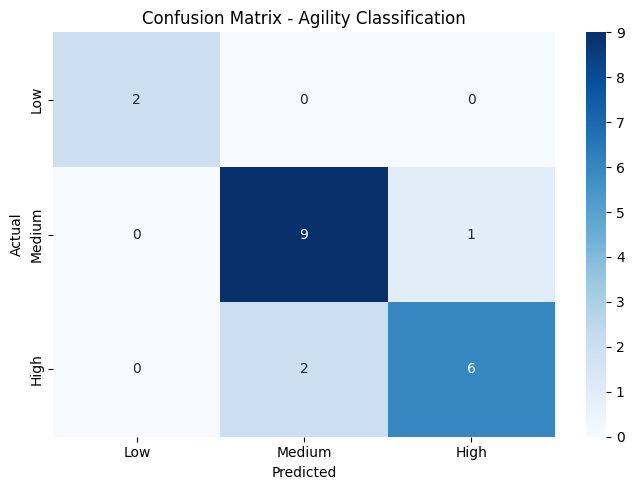

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Create agility categories
def categorize_agility(score):
    if score >= 3.67:
        return "High"
    elif score >= 2.34:
        return "Medium"
    else:
        return "Low"

df["Agility_Category"] = df["Agility_Score"].apply(categorize_agility)

# Features & target
X_cls = df[digital_cols]
y_cls = df["Agility_Category"]

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)

# Predictions
y_pred_c = clf.predict(X_test_c)


# Accuracy
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_c), 2))

# Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

# confusion matrix

cm = confusion_matrix(y_test_c, y_pred_c, labels=["Low", "Medium", "High"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Confusion Matrix - Agility Classification")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

The classification model achieved an accuracy of 85%, meaning it correctly predicted 17 out of 20 cases, which indicates strong overall performance. However, accuracy alone is not enough because it does not show how well the model performs for each category. That is why precision, recall, and F1-score were used. The F1-scores for the medium (0.86) and high (0.80) categories are high, showing that the model is good at both making correct predictions (precision) and identifying actual cases (recall). The F1-score is important because it combines both measures and gives a balanced evaluation of the model’s performance.

The low category achieved a perfect score (1.00), but this should be interpreted carefully because it is based on only 2 samples, making it easier for the model to appear perfect. The confusion matrix shows that the model performs very well, with most predictions correctly classified along the diagonal. The model perfectly predicts the low category, although it is based on a small number of samples. Most errors occur between the medium and high categories, which is expected due to their similarity. Importantly, the model does not make extreme errors, such as confusing low with high, indicating stable and reliable performance.